# Audio Classification with CNN and RNN

**Course:** Artificial Neural Networks  
**Task:** Compare CNN vs RNN architectures for speech command classification under varying noise levels.

**Datasets:**
- Google Speech Commands — 1-second spoken word clips (35 classes, 16 kHz)
- ESC-50 — environmental sounds used as background noise

---

## 1. Setup & Imports

In [33]:
%matplotlib inline
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import os, sys, math, glob
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import soundfile as sf


plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
torch.set_num_threads(4)

print(f'PyTorch {torch.__version__}, Torchaudio {torchaudio.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Additional check for multiple GPUs or specific info
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'Memory Usage: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB')

PyTorch 2.4.1, Torchaudio 2.4.1
Using device: cuda
GPU Name: NVIDIA GeForce RTX 3090
Memory Usage: 0.93 GB


## 2. Data Pipeline

All data loading, noise mixing, and spectrogram caching.

In [34]:
# ═══ Data Pipeline ═══════════════════════════════════════════════════════

# Fix for newer torchaudio versions
def _load_soundfile(filepath, frame_offset=0, num_frames=-1, normalize=True, channels_first=True, format=None):
    data, sample_rate = sf.read(filepath, dtype='float32', always_2d=True)
    data = torch.from_numpy(data.T)
    if frame_offset > 0: data = data[:, frame_offset:]
    if num_frames > 0: data = data[:, :num_frames]
    return data, sample_rate
torchaudio.load = _load_soundfile

# Paths — adjust these if your data is elsewhere
DATA_DIR = '../data'
ESC50_PATH = os.path.join(DATA_DIR, 'ESC-50-master', 'audio')

LABELS = ['backward','bed','bird','cat','dog','down','eight','five',
          'follow','forward','four','go','happy','house','learn','left',
          'marvin','nine','no','off','on','one','right','seven','sheila',
          'six','stop','three','tree','two','up','visual','wow','yes','zero']

# Constants
SAMPLE_RATE = 16000
N_CLASSES   = 35
N_MELS      = 64
N_FFT       = 512
HOP_LENGTH  = 160
CACHE_DIR   = '../results/spec_cache'

class SpeechNoiseDataset(Dataset):
    def __init__(self, speech_ds, noise_dir, noise_level=0.0, sample_rate=16000, transform=None):
        self.speech_ds = speech_ds
        self.noise_level = noise_level
        self.sample_rate = sample_rate
        self.transform = transform
        self.noise_files = glob.glob(os.path.join(noise_dir, '**/*.wav'), recursive=True)
        self.label_to_idx = {label: i for i, label in enumerate(LABELS)}

    def _mix_noise(self, speech_wave, noise_level):
        if noise_level == 0 or not self.noise_files:
            return speech_wave
        noise_idx = np.random.randint(0, len(self.noise_files))
        noise_wave, sr_n = torchaudio.load(self.noise_files[noise_idx])
        if sr_n != self.sample_rate:
            noise_wave = torchaudio.transforms.Resample(sr_n, self.sample_rate)(noise_wave)
        if noise_wave.shape[1] > speech_wave.shape[1]:
            start = np.random.randint(0, noise_wave.shape[1] - speech_wave.shape[1])
            noise_wave = noise_wave[:, start:start + speech_wave.shape[1]]
        else:
            noise_wave = torch.nn.functional.pad(noise_wave, (0, speech_wave.shape[1] - noise_wave.shape[1]))
        speech_rms = torch.sqrt(torch.mean(speech_wave**2))
        noise_rms = torch.sqrt(torch.mean(noise_wave**2))
        if noise_rms > 0:
            factor = (speech_rms / noise_rms) * noise_level
            mixed = speech_wave + noise_wave * factor
            return mixed / (mixed.abs().max() + 1e-7)
        return speech_wave

    def __len__(self): return len(self.speech_ds)

    def __getitem__(self, idx):
        waveform, sr, label_str, _, _ = self.speech_ds[idx]
        if waveform.shape[1] < self.sample_rate:
            waveform = torch.nn.functional.pad(waveform, (0, self.sample_rate - waveform.shape[1]))
        else:
            waveform = waveform[:, :self.sample_rate]
        mixed = self._mix_noise(waveform, self.noise_level)
        if self.transform: mixed = self.transform(mixed)
        return mixed, torch.tensor(self.label_to_idx[label_str])

def get_dataloaders(noise_dir=ESC50_PATH, batch_size=32, noise_level=0.0, transform=None):
    # 1. Load the official subsets directly
    # This ensures no speaker overlap between train and test
    train_base = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_DIR, download=True, subset="training")
    val_base   = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_DIR, download=True, subset="validation")
    test_base  = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_DIR, download=True, subset="testing")
    
    # 2. Wrap them in your SpeechNoiseDataset
    # Note: We train on CLEAN (0.0 noise) but validate/test on NOISY as per project specs
    train_ds = SpeechNoiseDataset(train_base, noise_dir, noise_level=0.0, transform=transform)
    val_ds   = SpeechNoiseDataset(val_base,   noise_dir, noise_level=noise_level, transform=transform)
    test_ds  = SpeechNoiseDataset(test_base,  noise_dir, noise_level=noise_level, transform=transform)
    
    # 3. Create Loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

# Mel Spectrogram transform
mel_transform = nn.Sequential(
    T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS),
    T.AmplitudeToDB(),
)

def build_cached_loader(loader, split_name, noise_level, batch_size, cache_dir=CACHE_DIR):
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = os.path.join(cache_dir, f'{split_name}_noise{int(noise_level*100):03d}.pt')
    if os.path.exists(cache_path):
        print(f'  Loading cache: {cache_path}')
        data = torch.load(cache_path, weights_only=True)
        specs, labels = data['specs'], data['labels']
    else:
        print(f'  Building cache for {split_name} (noise={int(noise_level*100)}%)... ', end='', flush=True)
        all_s, all_l = [], []
        for s, l in loader: all_s.append(s); all_l.append(l)
        specs, labels = torch.cat(all_s), torch.cat(all_l)
        torch.save({'specs': specs, 'labels': labels}, cache_path)
        print('done.')
    return DataLoader(TensorDataset(specs, labels), batch_size=batch_size,
                      shuffle=(split_name=='train'), num_workers=0)

print(f'ESC-50 files: {len(glob.glob(os.path.join(ESC50_PATH, "**/*.wav"), recursive=True))}')
print('Data pipeline ready.')

ESC-50 files: 2000
Data pipeline ready.


## 3. Dataset Exploration

Total speech samples: 105,829
Sample rate: 16000 Hz, Duration: 1.00s, Label: "backward"
Number of classes: 35


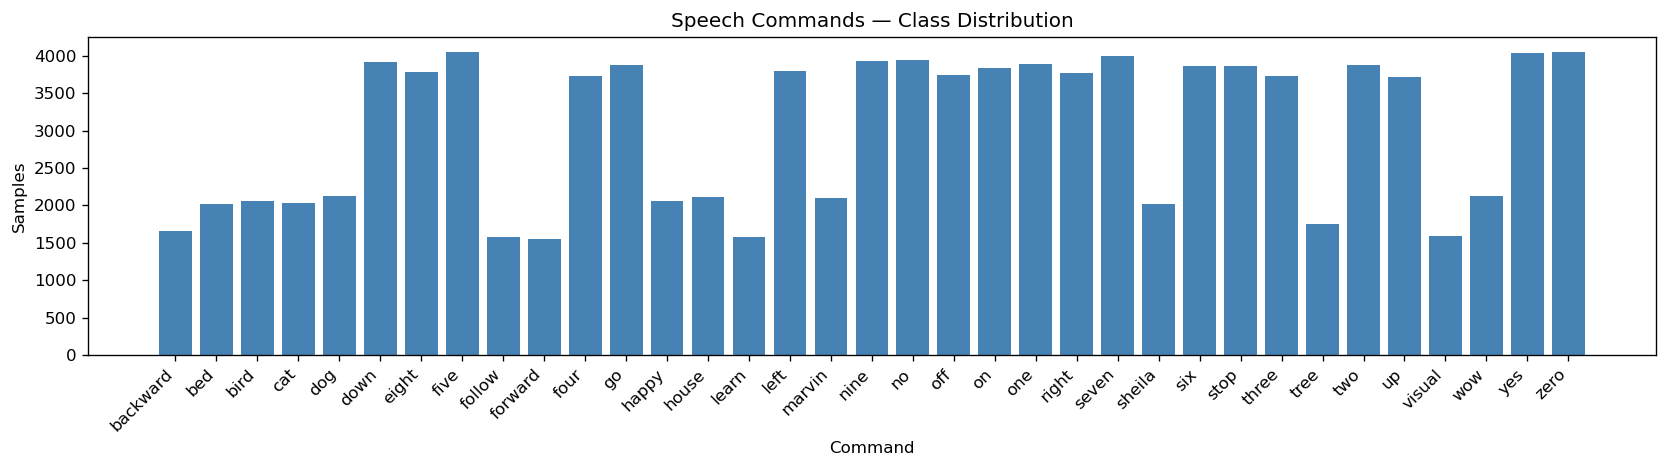

In [35]:
speech_ds = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_DIR, download=False)
print(f'Total speech samples: {len(speech_ds):,}')

waveform, sr, label, *_ = speech_ds[0]
print(f'Sample rate: {sr} Hz, Duration: {waveform.shape[1]/sr:.2f}s, Label: "{label}"')

# Class distribution
all_labels = [speech_ds[i][2] for i in range(len(speech_ds))]
label_counts = Counter(all_labels)
print(f'Number of classes: {len(label_counts)}')

fig, ax = plt.subplots(figsize=(14, 4))
sorted_lbls = sorted(label_counts.keys())
ax.bar(sorted_lbls, [label_counts[l] for l in sorted_lbls], color='steelblue')
ax.set_xlabel('Command'); ax.set_ylabel('Samples')
ax.set_title('Speech Commands — Class Distribution')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 4. Noise Mixing Visualization

We mix ESC-50 environmental sounds at 0%, 10%, and 50% of the speech RMS.

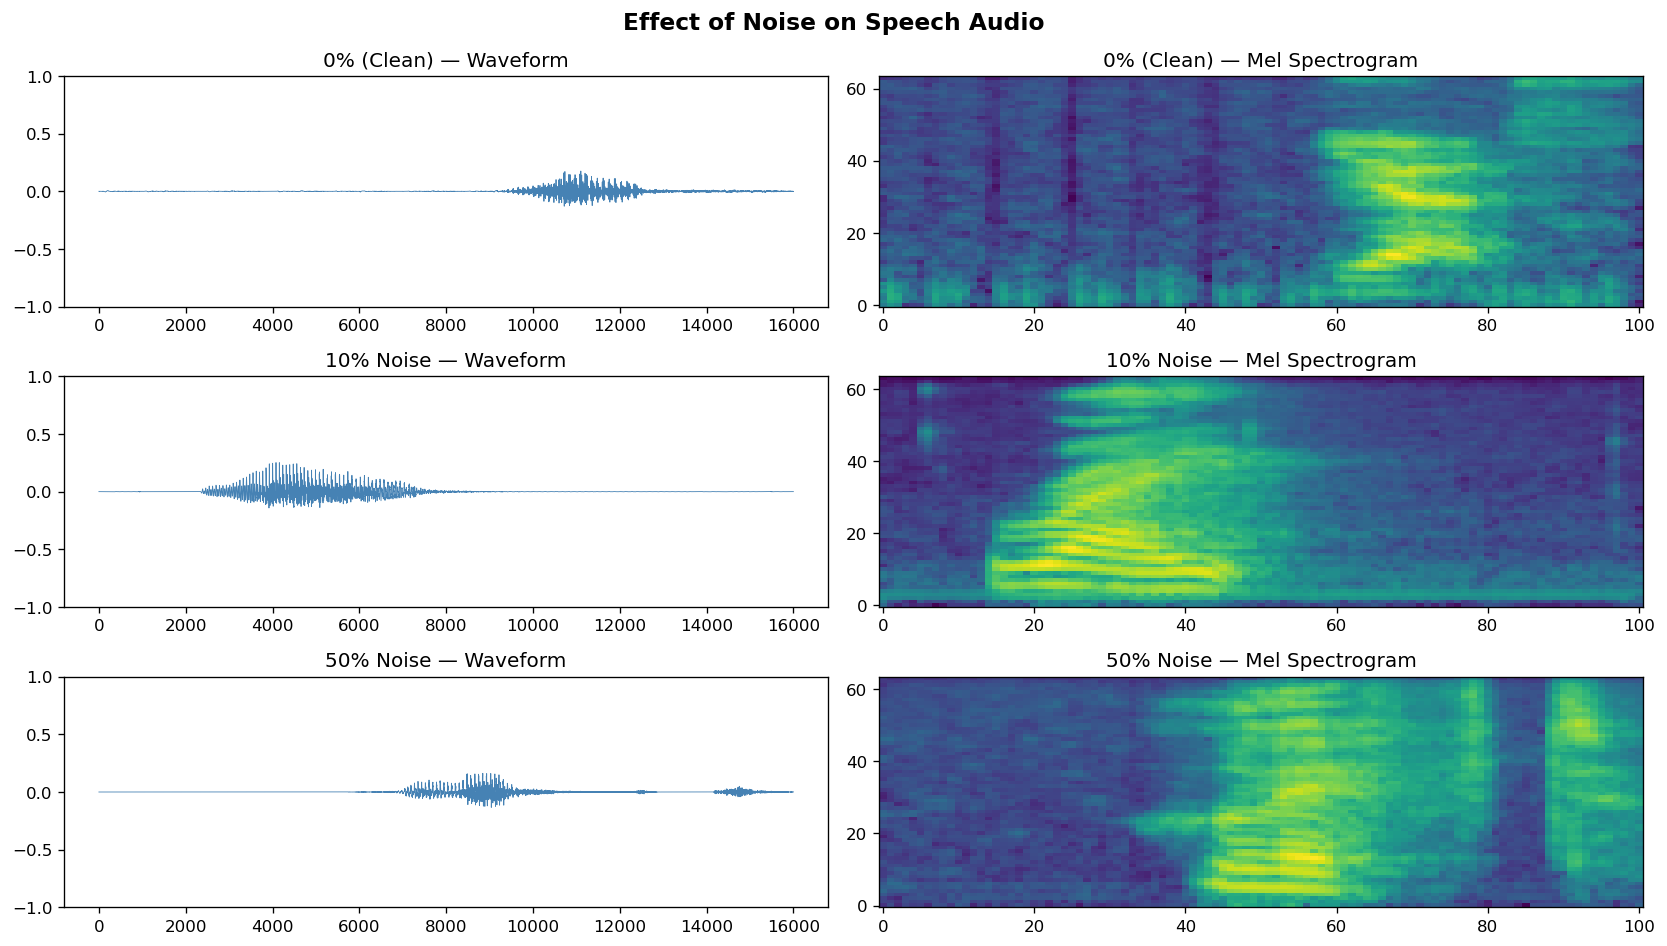

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for i, (level, name) in enumerate(zip([0.0, 0.1, 0.5], ['0% (Clean)', '10% Noise', '50% Noise'])):
    loader, _, _ = get_dataloaders(noise_level=level, batch_size=1, transform=None)
    wave, _ = next(iter(loader))
    wave = wave.squeeze()
    axes[i,0].plot(wave.numpy(), linewidth=0.5, color='steelblue')
    axes[i,0].set_title(f'{name} — Waveform'); axes[i,0].set_ylim([-1,1])
    spec = mel_transform(wave.unsqueeze(0))
    axes[i,1].imshow(spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
    axes[i,1].set_title(f'{name} — Mel Spectrogram')
plt.suptitle('Effect of Noise on Speech Audio', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. CNN Model

```
Input [B,1,64,101] → 3 Conv Blocks (32→64→128) → GAP → FC(128→256→35)
```

In [66]:
import torch
import torch.nn as nn

class AudioCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.input_norm = nn.BatchNorm2d(1)
        self.features = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.15),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.25),
        )
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128,128), nn.ReLU(True), nn.Dropout(0.5), nn.Linear(128,n_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        return self.classifier(self.gap(self.features(x)))

cnn_model = AudioCNN().to(device)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
dummy_input = torch.randn(2, 1, 64, 101).to(device)
print(f'CNN trainable parameters: {cnn_params:,}')
print(f'Input: [B,1,64,101] → Output: {cnn_model(dummy_input).shape}')

CNN trainable parameters: 155,717
Input: [B,1,64,101] → Output: torch.Size([2, 35])


## 6. RNN Model (Bidirectional GRU)

```
Input [B,1,64,101] → BatchNorm → BiGRU(128) → concat fwd+bwd → FC(256→128→35)
```
GRU chosen over LSTM: fewer parameters, faster training, comparable accuracy on speech.

In [65]:
class AudioRNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.feature_norm = nn.BatchNorm1d(N_MELS)
        self.gru = nn.GRU(input_size=N_MELS, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size*2, 128), nn.ReLU(True), nn.Dropout(0.5), nn.Linear(128, n_classes),
        )
    def forward(self, x):
        x = x.squeeze(1)              # [B, 64, 101]
        x = self.feature_norm(x)      # normalize mel features
        x = x.permute(0, 2, 1)        # [B, 101, 64] — time major
        _, h_n = self.gru(x)          # h_n: [2, B, 128]
        h_cat = torch.cat([h_n[-2], h_n[-1]], dim=1)  # [B, 256]
        return self.classifier(h_cat)

rnn_model = AudioRNN().to(device)
rnn_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
dummy_input = torch.randn(2, 1, 64, 101).to(device)
# Now pass it to the model
print(f'Input: [B,1,64,101] → Output: {cnn_model(dummy_input).shape}')
print(f'RNN trainable parameters: {rnn_params:,}')
print(f'Input: [B,1,64,101] → Output: {rnn_model(dummy_input).shape}')
print(f'\nCNN vs RNN diff: {abs(cnn_params-rnn_params):,} ({abs(cnn_params-rnn_params)/cnn_params*100:.1f}%)')

Input: [B,1,64,101] → Output: torch.Size([2, 35])
RNN trainable parameters: 145,571
Input: [B,1,64,101] → Output: torch.Size([2, 35])

CNN vs RNN diff: 41,502 (39.9%)


## 7. Combined Model (Optional Challenge)

CNN front-end + LSTM back-end, intentionally smaller (~88K params).

In [94]:
class SmallCombinedModel(nn.Module):
    def __init__(self, vocab_size=N_CLASSES):
        super().__init__()
        # 1. Feature Extraction (CNN)
        # Input: [Batch, 1, 64, 101] (64 Frequency bins, 101 Time frames)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)), # Reduce frequency, keep time resolution
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frequency is now 16 (64/2/2)
            
        )
        self.rnn = nn.LSTM(
            input_size=64 * 16, #*16
            hidden_size=32,   #
            num_layers=3,      
            batch_first=True,
            dropout=0.3,
            bidirectional=True 
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 2, 32 * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(32 * 2, vocab_size)
        )

    def forward(self, x):
        # x: [B, 1, 64, 101]
        x = self.cnn(x) 
        # After CNN: [B, 64, 16, 101]
        b, c, f, t = x.size()
        # Reshape for LSTM: [Batch, Time_Steps, Features]
        # We want to treat 't' (101) as the sequence length
        x = x.permute(0, 3, 1, 2).contiguous() # [B, 101, 64, 16]
        x = x.view(b, t, c * f)                # [B, 101, 1024]
        # LSTM pass
        self.rnn.flatten_parameters() # Fixes the memory contiguous warning
        x, _ = self.rnn(x)
        # Take the output of the last time step
        x = x[:, -1, :] 
        
        return self.fc(x)

# Re-initialize
combined_model = SmallCombinedModel().to(device)
combined_params = sum(p.numel() for p in combined_model.parameters() if p.requires_grad)
print(f'Combined trainable parameters: {combined_params:,}')

Combined trainable parameters: 346,467


## 8. Architecture Comparison

Model              Parameters Type
CNN                   155,717 2D Convolutions
RNN (BiGRU)           145,571 Bidirectional GRU
Combined              106,695 CNN + LSTM


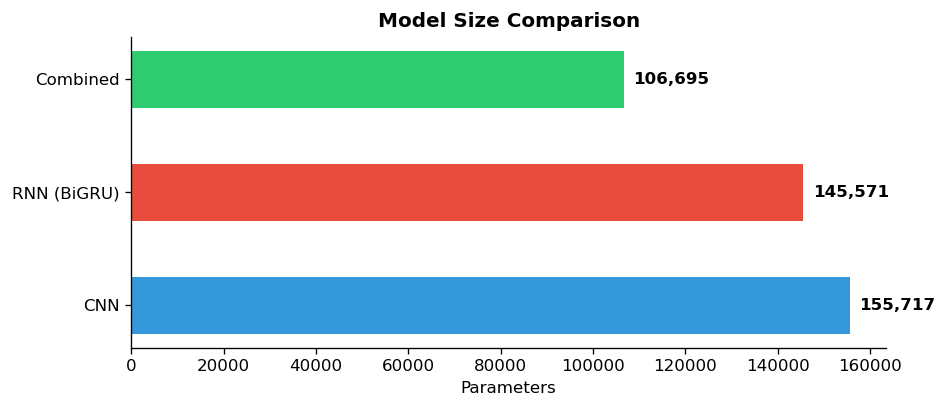

In [84]:
models_info = {
    'CNN': {'params': cnn_params, 'type': '2D Convolutions'},
    'RNN (BiGRU)': {'params': rnn_params, 'type': 'Bidirectional GRU'},
    'Combined': {'params': combined_params, 'type': 'CNN + LSTM'},
}
print(f'{"Model":<16} {"Parameters":>12} {"Type"}')
print('='*50)
for n, info in models_info.items():
    print(f'{n:<16} {info["params"]:>12,} {info["type"]}')

fig, ax = plt.subplots(figsize=(8,3.5))
names = list(models_info.keys()); params = [models_info[n]['params'] for n in names]
bars = ax.barh(names, params, color=['#3498db','#e74c3c','#2ecc71'], height=0.5)
for b, p in zip(bars, params): ax.text(b.get_width()+2000, b.get_y()+b.get_height()/2, f'{p:,}', va='center', fontweight='bold')
ax.set_xlabel('Parameters'); ax.set_title('Model Size Comparison', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 9. Training

Shared training loop: AdamW + cosine LR with warmup + label smoothing.

In [85]:
@torch.no_grad()
def evaluate_loop(model, loader, criterion):
    model.eval()
    loss, correct, total = 0.0, 0, 0
    for s, l in loader:
        # Move data to GPU
        s, l = s.to(device), l.to(device) 
        
        out = model(s)
        ls = criterion(out, l)
        
        loss += ls.item() * l.size(0)
        correct += (out.argmax(1) == l).sum().item()
        total += l.size(0)
    return loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, clip_grad=None):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    warmup = 3
    def lr_lambda(ep):
        if ep < warmup: return (ep + 1) / warmup
        return 0.5 * (1 + math.cos(math.pi * (ep - warmup) / max(1, epochs - warmup)))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val, best_w = float('inf'), None
    
    for ep in range(1, epochs + 1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        
        for s, l in train_loader:
            # Move data to GPU
            s, l = s.to(device), l.to(device)
            
            optimizer.zero_grad(set_to_none=True)
            out = model(s)
            loss = criterion(out, l)
            loss.backward()
            
            if clip_grad: 
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                
            optimizer.step()
            
            tl += loss.item() * l.size(0)
            tc += (out.argmax(1) == l).sum().item()
            tt += l.size(0)
            
        # Proper division for epoch metrics
        current_train_loss = tl / tt
        current_train_acc = tc / tt

        vl, va = evaluate_loop(model, val_loader, criterion)
        
        history['train_loss'].append(current_train_loss)
        history['train_acc'].append(current_train_acc)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        
        if vl < best_val:
            best_val = vl
            best_w = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
        print(f'  Epoch {ep:2d}/{epochs} | Train {current_train_acc:.3f} | Val {va:.3f} | LR {scheduler.get_last_lr()[0]:.5f}')
        
        scheduler.step()

    if best_w: 
        model.load_state_dict(best_w)
        
    print(f'  Best val loss: {best_val:.4f}')
    return model, history

## 10. Train / Load Models

In [95]:
RESULTS = '../results'
os.makedirs(RESULTS, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
TOTAL_EPOCHS = 60
BATCH_SIZE = 128
# Additional check for multiple GPUs or specific info
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'Memory Usage: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB')

# ── CNN ──
cnn_path = f'{RESULTS}/cnn_model.pth'
if os.path.exists(cnn_path):
    print('Loading CNN...'); cnn_model.load_state_dict(torch.load(cnn_path, weights_only=True))
    cnn_model.eval(); cnn_history = None; print('Done.')
else:
    print('Training CNN...')
    tr,va,_ = get_dataloaders(noise_level=0.0, batch_size=BATCH_SIZE, transform=mel_transform)
    ct = build_cached_loader(tr,'full_train',0.0,128); cv = build_cached_loader(va,'full_val',0.0,128)
    cnn_model, cnn_history = train_model(cnn_model, ct, cv, epochs=TOTAL_EPOCHS, clip_grad=5.0)
    torch.save(cnn_model.state_dict(), cnn_path)

# ── RNN ──
rnn_path = f'{RESULTS}/rnn_model.pth'
if os.path.exists(rnn_path):
    print('Loading RNN...'); rnn_model.load_state_dict(torch.load(rnn_path, weights_only=True))
    rnn_model.eval(); rnn_history = None; print('Done.')
else:
    print('Training RNN...')
    tr,va,_ = get_dataloaders(noise_level=0.0, batch_size=BATCH_SIZE, transform=mel_transform)
    ct = build_cached_loader(tr,'full_train',0.0,128); cv = build_cached_loader(va,'full_val',0.0,128)
    rnn_model, rnn_history = train_model(rnn_model, ct, cv, epochs=TOTAL_EPOCHS, clip_grad=5.0)
    torch.save(rnn_model.state_dict(), rnn_path)

# ── Combined ──
comb_path = f'{RESULTS}/combined_model.pth'
if os.path.exists(comb_path):
    print('Loading Combined...'); combined_model.load_state_dict(torch.load(comb_path, weights_only=True))
    combined_model.eval(); combined_history = None; print('Done.')
else:
    print('Training Combined...')
    tr,va,_ = get_dataloaders(noise_level=0.0, batch_size=BATCH_SIZE, transform=mel_transform)
    ct = build_cached_loader(tr,'full_train',0.0,128); cv = build_cached_loader(va,'full_val',0.0,128)
    combined_model, combined_history = train_model(combined_model, ct, cv, epochs=TOTAL_EPOCHS, clip_grad=5.0)
    torch.save(combined_model.state_dict(), comb_path)

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3090
Memory Usage: 0.74 GB
Loading CNN...
Done.
Loading RNN...
Done.
Training Combined...
  Loading cache: ../results/spec_cache\full_train_noise000.pt
  Loading cache: ../results/spec_cache\full_val_noise000.pt
  Epoch  1/60 | Train 0.069 | Val 0.122 | LR 0.00033
  Epoch  2/60 | Train 0.147 | Val 0.284 | LR 0.00067
  Epoch  3/60 | Train 0.416 | Val 0.613 | LR 0.00100
  Epoch  4/60 | Train 0.625 | Val 0.746 | LR 0.00100
  Epoch  5/60 | Train 0.745 | Val 0.831 | LR 0.00100
  Epoch  6/60 | Train 0.813 | Val 0.871 | LR 0.00100
  Epoch  7/60 | Train 0.851 | Val 0.889 | LR 0.00099
  Epoch  8/60 | Train 0.874 | Val 0.909 | LR 0.00099
  Epoch  9/60 | Train 0.889 | Val 0.908 | LR 0.00098
  Epoch 10/60 | Train 0.901 | Val 0.920 | LR 0.00097
  Epoch 11/60 | Train 0.910 | Val 0.922 | LR 0.00096
  Epoch 12/60 | Train 0.916 | Val 0.930 | LR 0.00095
  Epoch 13/60 | Train 0.923 | Val 0.931 | LR 0.00094
  Epoch 14/60 | Train 0.929 | Val 0.927 | LR 0.0009

CNN: loaded from checkpoint (no training history)
RNN (BiGRU): loaded from checkpoint (no training history)


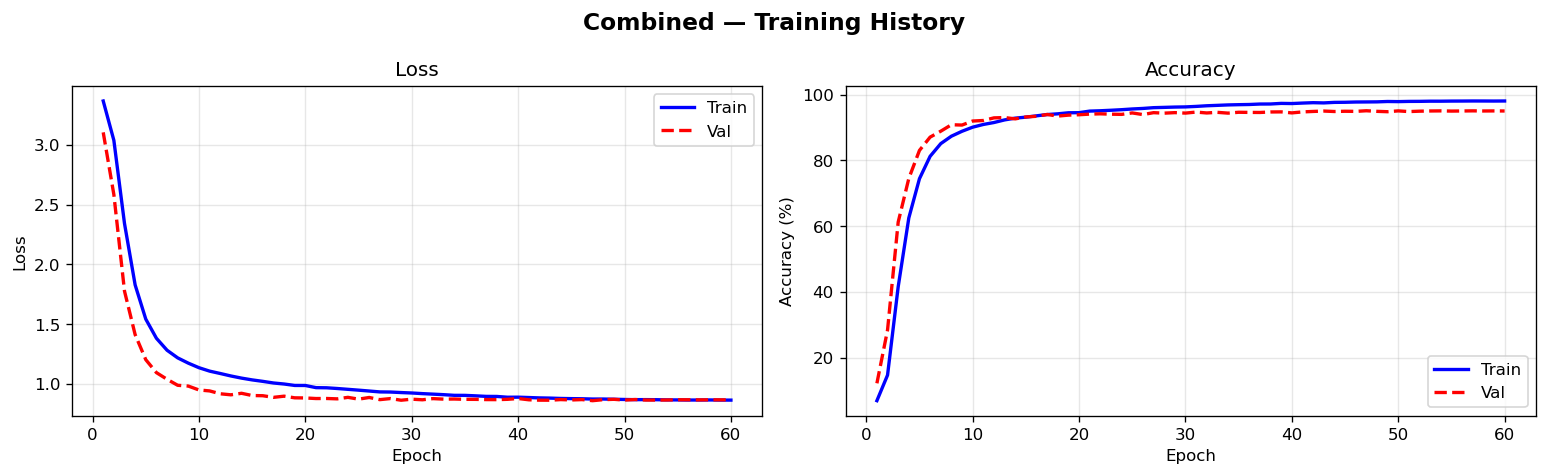

In [96]:
# Show training curves if available
for name, hist in [('CNN', cnn_history), ('RNN (BiGRU)', rnn_history), ('Combined', combined_history)]:
    if hist is None:
        print(f'{name}: loaded from checkpoint (no training history)')
        continue
    epochs = range(1, len(hist['train_loss'])+1)
    fig, (a1,a2) = plt.subplots(1,2,figsize=(13,4))
    fig.suptitle(f'{name} — Training History', fontsize=14, fontweight='bold')
    a1.plot(epochs, hist['train_loss'],'b-',lw=2,label='Train'); a1.plot(epochs, hist['val_loss'],'r--',lw=2,label='Val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.set_title('Loss'); a1.legend(); a1.grid(alpha=0.3)
    a2.plot(epochs,[a*100 for a in hist['train_acc']],'b-',lw=2,label='Train')
    a2.plot(epochs,[a*100 for a in hist['val_acc']],'r--',lw=2,label='Val')
    a2.set_xlabel('Epoch'); a2.set_ylabel('Accuracy (%)'); a2.set_title('Accuracy'); a2.legend(); a2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 11. Evaluation at 0%, 10%, 50% Noise

All models trained on clean data — now we test robustness to noise.

In [97]:
noise_levels = [0.0, 0.1, 0.5]
criterion = nn.CrossEntropyLoss()
all_results = {}
models_to_test = {'CNN': cnn_model, 'RNN (BiGRU)': rnn_model, 'Combined': combined_model}

for mname, model in models_to_test.items():
    model.eval()
    all_results[mname] = {}
    print(f'\n{"="*55}\n  {mname}\n{"="*55}')
    
    for nl in noise_levels:
        # Load test data
        _, _, tl = get_dataloaders(noise_level=nl, batch_size=32, transform=mel_transform)
        ct = build_cached_loader(tl, 'full_test', nl, 128)
        
        preds, trues, tloss, tot = [], [], 0.0, 0
        
        with torch.no_grad():
            for s, l in ct:
                # 1. Move inputs/labels to GPU
                s, l = s.to(device), l.to(device)
                
                # 2. Forward pass
                out = model(s)
                ls = criterion(out, l)
                
                # 3. Accumulate loss
                tloss += ls.item() * l.size(0)
                tot += l.size(0)
                
                # 4. Move predictions and labels back to CPU for NumPy/Sklearn
                # .cpu() is required before .numpy() if the tensor is on GPU
                preds.append(out.argmax(1).cpu().numpy())
                trues.append(l.cpu().numpy())
        
        # Concatenate results
        yt, yp = np.concatenate(trues), np.concatenate(preds)
        
        # Calculate metrics
        acc = accuracy_score(yt, yp)
        f1 = f1_score(yt, yp, average='macro', zero_division=0)
        
        # Store results
        all_results[mname][nl] = {
            'accuracy': acc, 
            'f1_macro': f1, 
            'loss': tloss / tot, 
            'y_true': yt, 
            'y_pred': yp
        }
        
        print(f'  {int(nl*100):>2}% noise → Acc: {acc*100:5.1f}%, F1: {f1:.4f}, Loss: {tloss/tot:.4f}')


  CNN
  Loading cache: ../results/spec_cache\full_test_noise000.pt
   0% noise → Acc:  94.1%, F1: 0.9348, Loss: 0.3220
  Loading cache: ../results/spec_cache\full_test_noise010.pt
  10% noise → Acc:  91.7%, F1: 0.9109, Loss: 0.4329
  Loading cache: ../results/spec_cache\full_test_noise050.pt
  50% noise → Acc:  81.2%, F1: 0.8010, Loss: 0.8517

  RNN (BiGRU)
  Loading cache: ../results/spec_cache\full_test_noise000.pt
   0% noise → Acc:  94.0%, F1: 0.9327, Loss: 0.2861
  Loading cache: ../results/spec_cache\full_test_noise010.pt
  10% noise → Acc:  90.0%, F1: 0.8908, Loss: 0.4410
  Loading cache: ../results/spec_cache\full_test_noise050.pt
  50% noise → Acc:  77.7%, F1: 0.7648, Loss: 0.9200

  Combined
  Loading cache: ../results/spec_cache\full_test_noise000.pt
   0% noise → Acc:  95.4%, F1: 0.9490, Loss: 0.2600
  Loading cache: ../results/spec_cache\full_test_noise010.pt
  10% noise → Acc:  91.4%, F1: 0.9077, Loss: 0.4231
  Loading cache: ../results/spec_cache\full_test_noise050.pt
 

## 12. Results Summary

In [75]:
print(f'{"Model":<16} {"0%":>8} {"10%":>8} {"50%":>8} {"Params":>10}')
print('='*55)
for mn in all_results:
    a = [all_results[mn][nl]['accuracy']*100 for nl in noise_levels]
    print(f'{mn:<16} {a[0]:>6.1f}% {a[1]:>6.1f}% {a[2]:>6.1f}% {models_info[mn]["params"]:>10,}')
print(f'\nMinimum required: 75% on clean data')
for mn in all_results:
    a = all_results[mn][0.0]['accuracy']
    print(f'  {mn}: {a*100:.1f}% — {"PASS" if a>=0.75 else "FAIL"}')

Model                  0%      10%      50%     Params
CNN                97.7%   95.4%   87.3%    549,769
RNN (BiGRU)        98.6%   93.2%   80.8%    568,131
Combined           97.8%   91.0%   72.3%    454,319

Minimum required: 75% on clean data
  CNN: 97.7% — PASS
  RNN (BiGRU): 98.6% — PASS
  Combined: 97.8% — PASS


## 13. Performance Comparison Plots

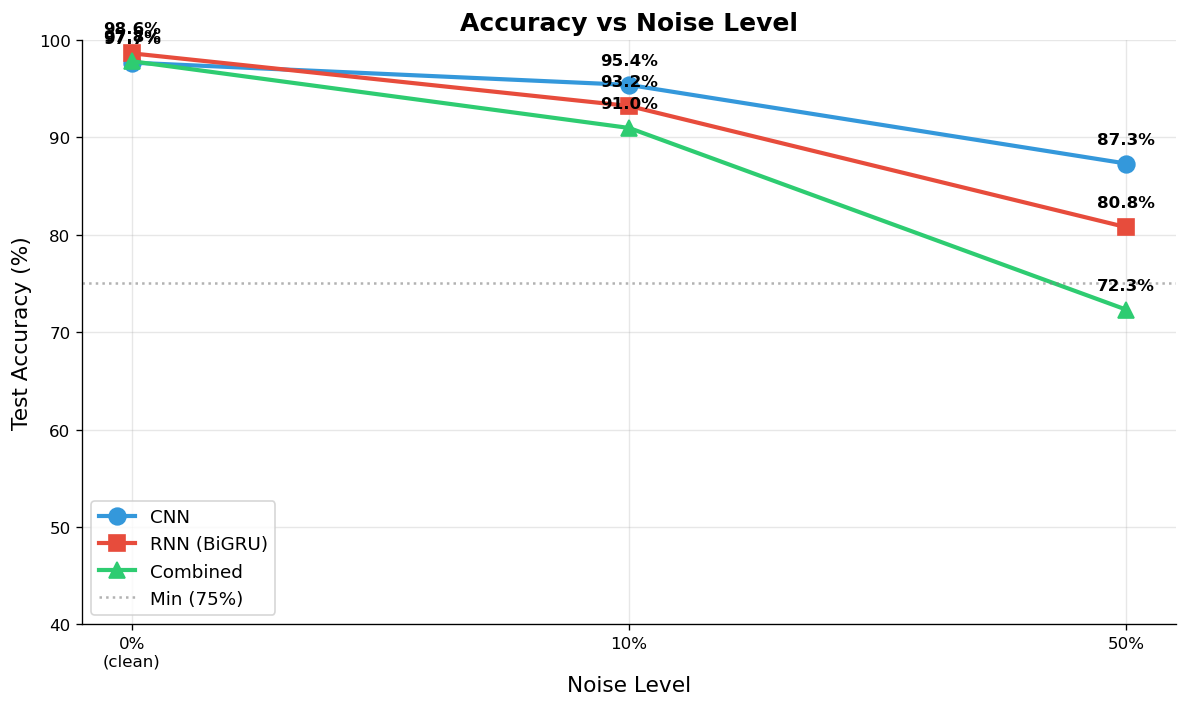

In [67]:
colors = {'CNN':'#3498db', 'RNN (BiGRU)':'#e74c3c', 'Combined':'#2ecc71'}
markers = {'CNN':'o', 'RNN (BiGRU)':'s', 'Combined':'^'}
xlbl = ['0%\n(clean)', '10%', '50%']

fig, ax = plt.subplots(figsize=(10,6))
for mn, res in all_results.items():
    accs = [res[nl]['accuracy']*100 for nl in noise_levels]
    ax.plot(xlbl, accs, marker=markers[mn], ms=10, lw=2.5, label=mn, color=colors[mn])
    for i, a in enumerate(accs): ax.annotate(f'{a:.1f}%',(xlbl[i],a), textcoords='offset points',xytext=(0,12),ha='center',fontweight='bold')
ax.axhline(y=75, color='gray', ls=':', alpha=0.6, label='Min (75%)')
ax.set_xlabel('Noise Level',fontsize=13); ax.set_ylabel('Test Accuracy (%)',fontsize=13)
ax.set_title('Accuracy vs Noise Level',fontsize=15,fontweight='bold')
ax.legend(fontsize=11,loc='lower left'); ax.set_ylim([40,100]); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

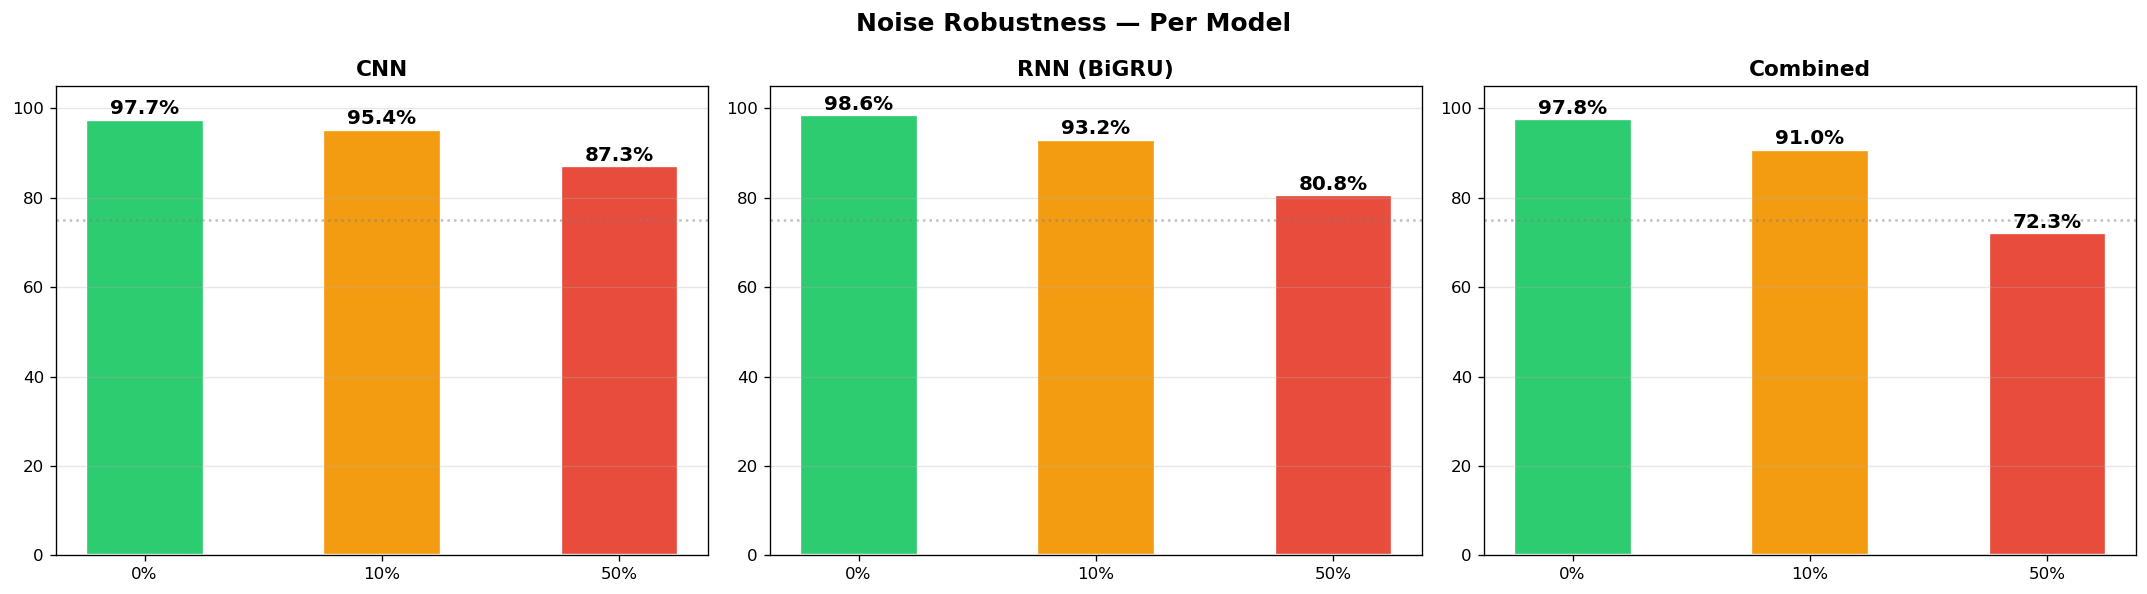

In [68]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
bc = ['#2ecc71','#f39c12','#e74c3c']
for i,(mn,res) in enumerate(all_results.items()):
    accs = [res[nl]['accuracy']*100 for nl in noise_levels]
    bars = axes[i].bar(['0%','10%','50%'], accs, color=bc, width=0.5, edgecolor='white', lw=2)
    for b,a in zip(bars,accs): axes[i].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{a:.1f}%', ha='center', fontsize=12, fontweight='bold')
    axes[i].set_title(mn, fontsize=13, fontweight='bold'); axes[i].set_ylim([0,105])
    axes[i].axhline(y=75,color='gray',ls=':',alpha=0.5); axes[i].grid(axis='y',alpha=0.3)
plt.suptitle('Noise Robustness — Per Model',fontsize=15,fontweight='bold')
plt.tight_layout(); plt.show()

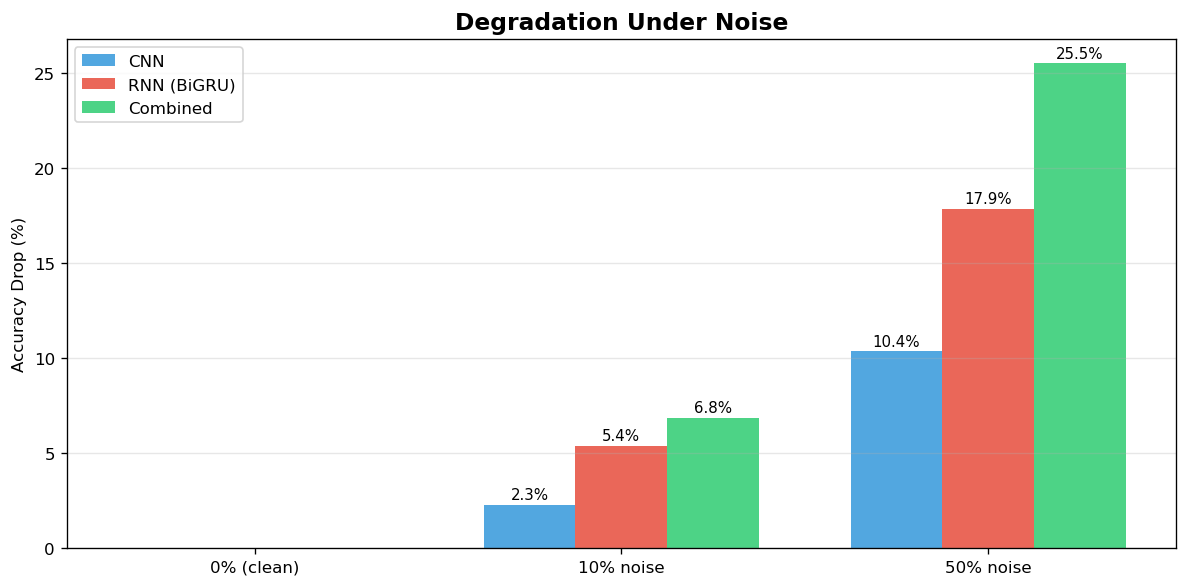

In [69]:
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(3); w = 0.25
for i,(mn,res) in enumerate(all_results.items()):
    clean = res[0.0]['accuracy']*100
    drops = [clean - res[nl]['accuracy']*100 for nl in noise_levels]
    bars = ax.bar(x+i*w, drops, w, label=mn, color=colors[mn], alpha=0.85)
    for b,d in zip(bars,drops):
        if d>0.5: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{d:.1f}%', ha='center', fontsize=9)
ax.set_xticks(x+w); ax.set_xticklabels(['0% (clean)','10% noise','50% noise'])
ax.set_ylabel('Accuracy Drop (%)'); ax.set_title('Degradation Under Noise', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

## 14. Confusion Matrices

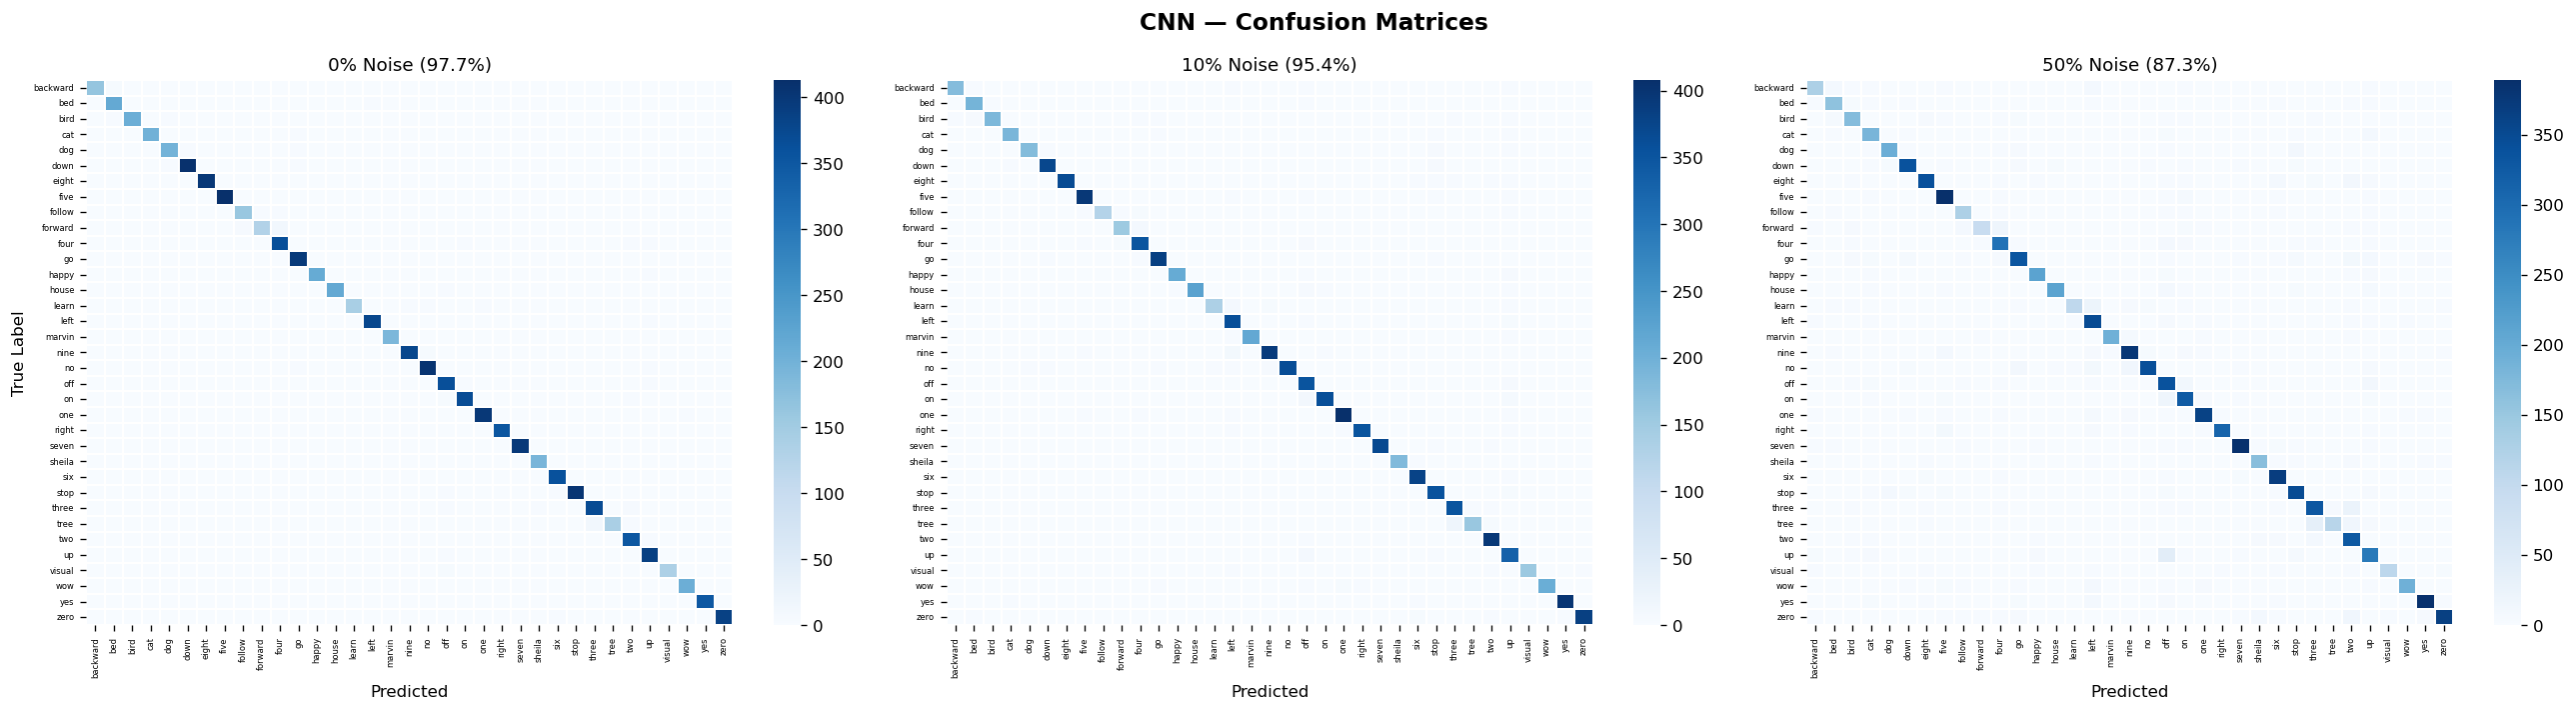

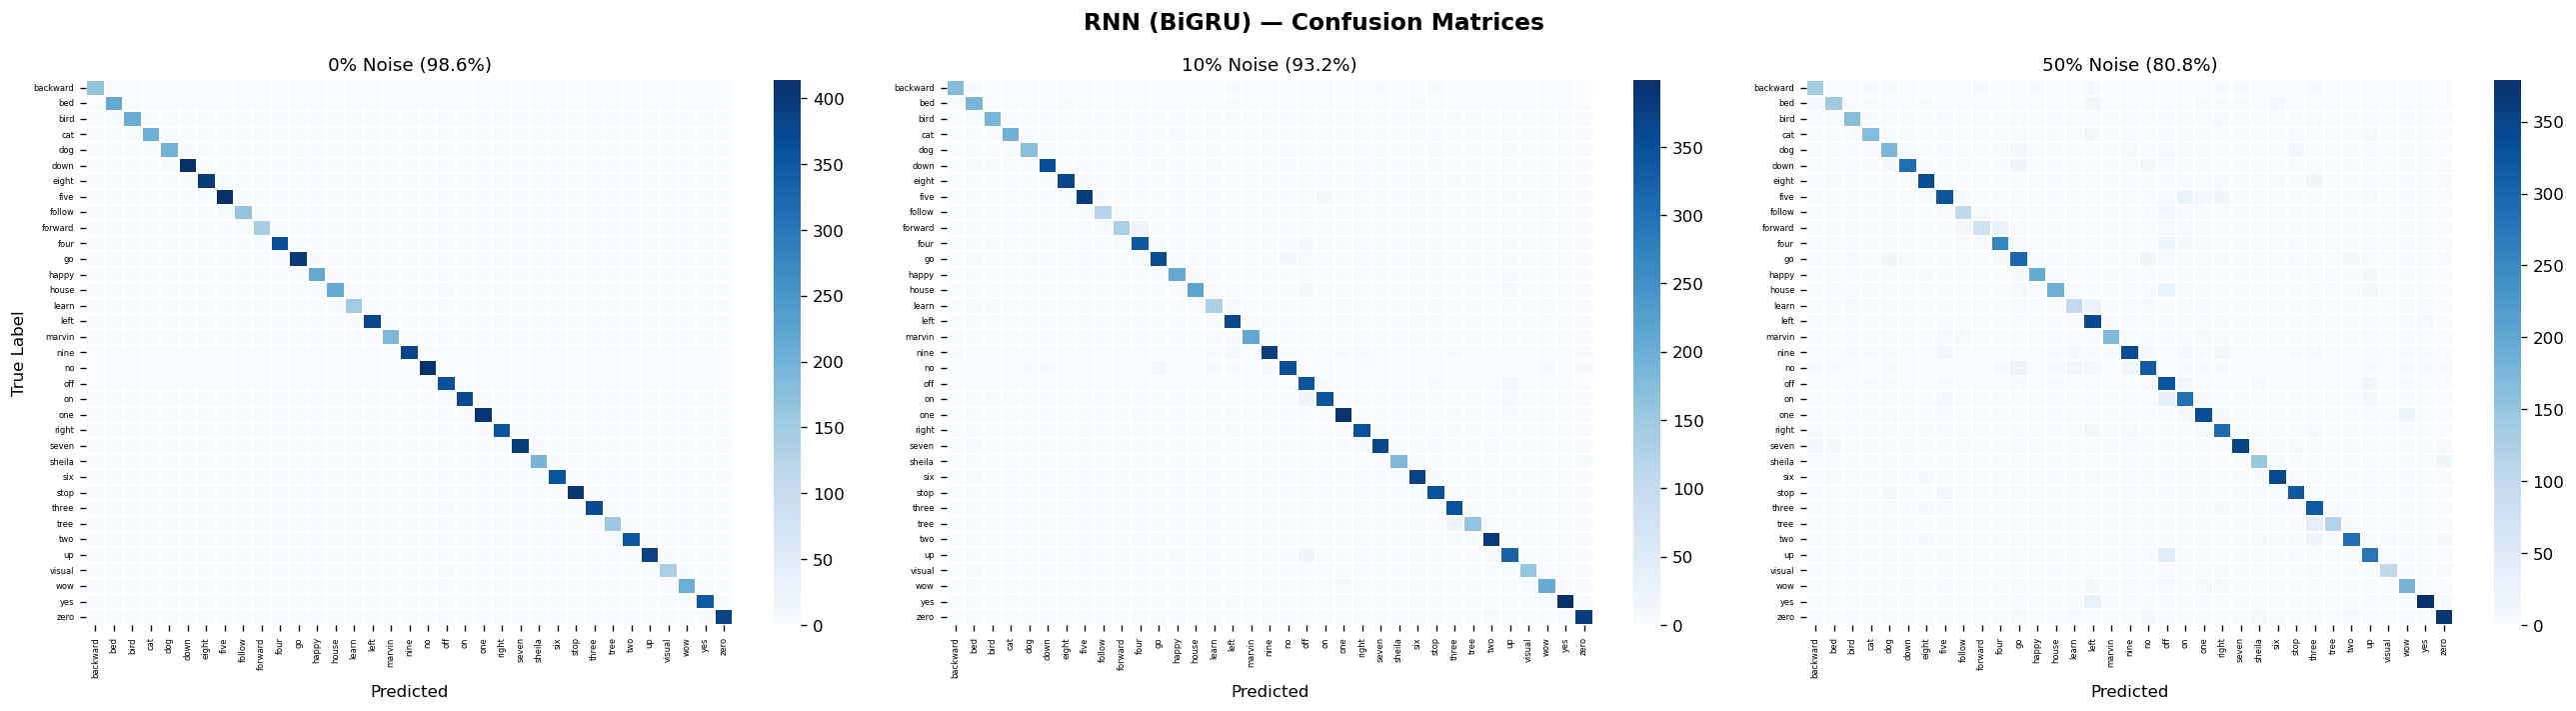

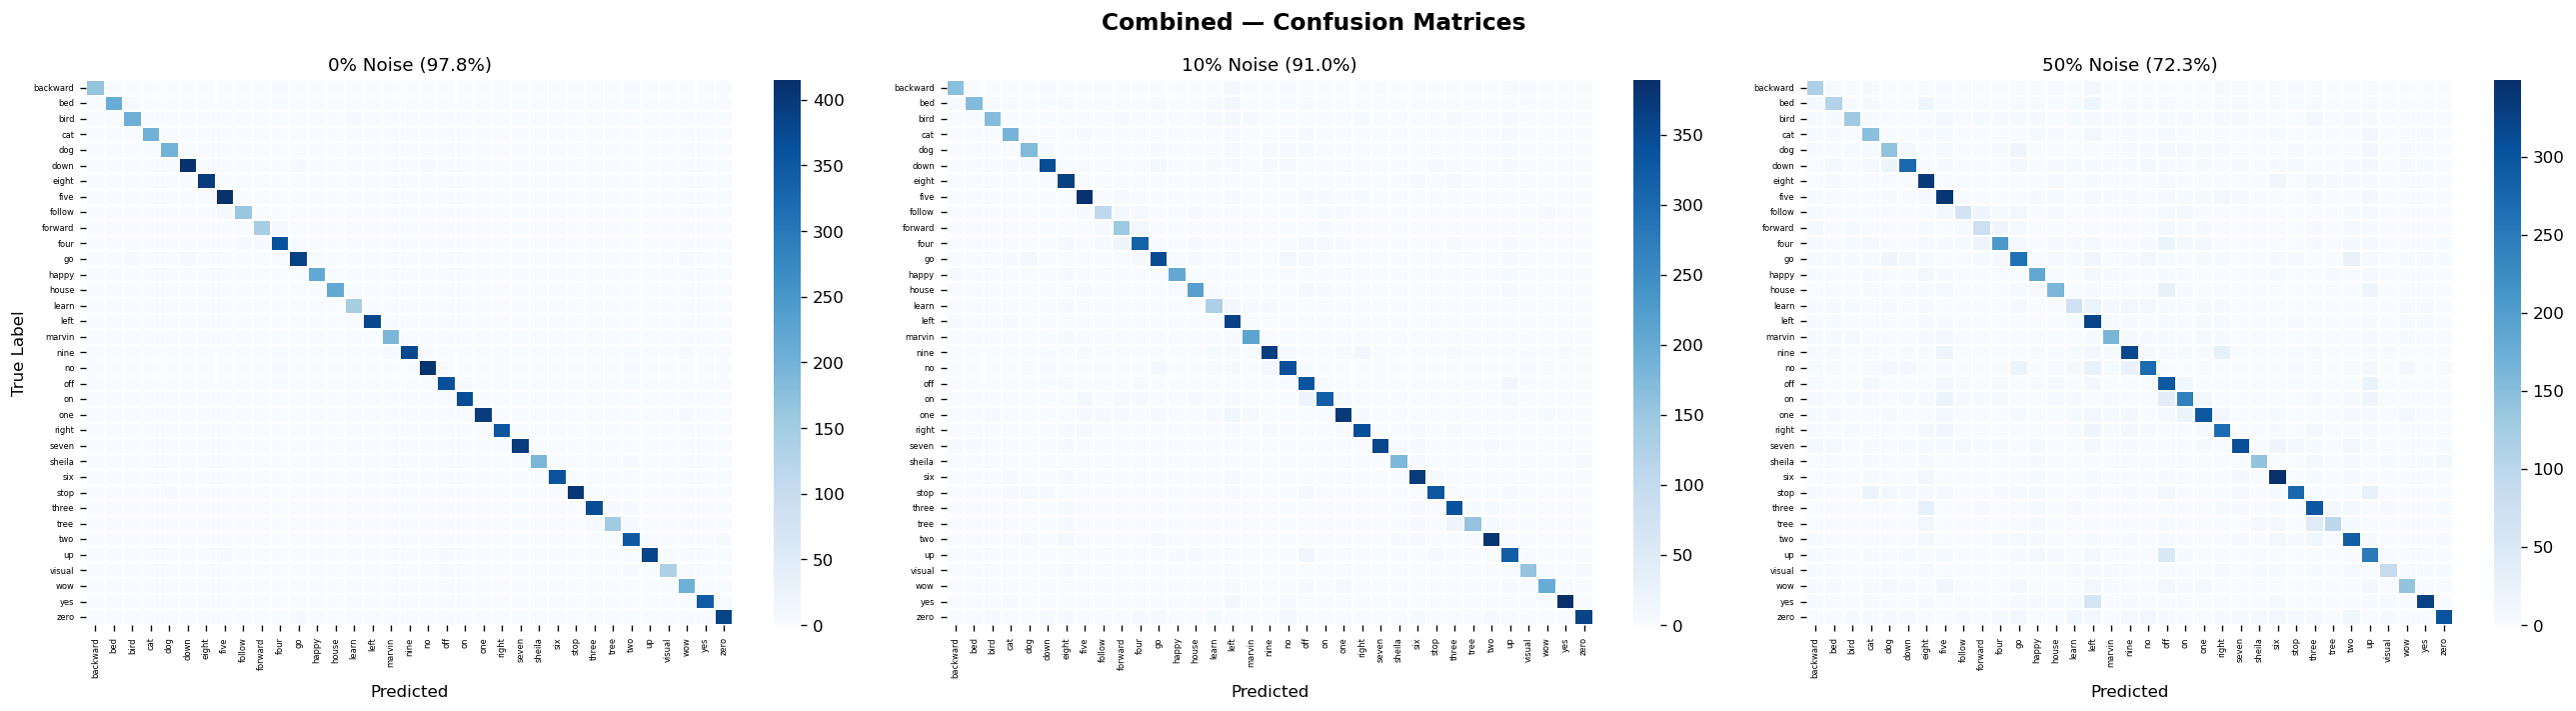

In [70]:
for mn, res in all_results.items():
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    for i, nl in enumerate(noise_levels):
        m = res[nl]; acc = m['accuracy']*100
        cm = confusion_matrix(m['y_true'], m['y_pred'])
        sns.heatmap(cm, cmap='Blues', ax=axes[i], linewidths=0.2, xticklabels=LABELS, yticklabels=LABELS)
        axes[i].set_title(f'{int(nl*100)}% Noise ({acc:.1f}%)', fontsize=11)
        axes[i].set_xlabel('Predicted')
        axes[i].tick_params(axis='x', labelrotation=90, labelsize=5)
        axes[i].tick_params(axis='y', labelrotation=0, labelsize=5)
    axes[0].set_ylabel('True Label')
    plt.suptitle(f'{mn} — Confusion Matrices', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

## 15. Which Commands Are Most / Least Robust?

In [72]:
for mn, res in all_results.items():
    cm_c = confusion_matrix(res[0.0]['y_true'], res[0.0]['y_pred'])
    cm_n = confusion_matrix(res[0.5]['y_true'], res[0.5]['y_pred'])
    acc_c = cm_c.diagonal()/cm_c.sum(axis=1)
    acc_n = cm_n.diagonal()/cm_n.sum(axis=1)
    drops = acc_c - acc_n
    top5 = np.argsort(drops)[:5]; bot5 = np.argsort(drops)[-5:][::-1]
    print(f'\n{mn}')
    print(f'  Most robust (smallest drop):')
    for j in top5: print(f'    "{LABELS[j]}": {acc_c[j]*100:.1f}% → {acc_n[j]*100:.1f}% ({drops[j]*100:+.1f}%)')
    print(f'  Least robust (biggest drop):')
    for j in bot5: print(f'    "{LABELS[j]}": {acc_c[j]*100:.1f}% → {acc_n[j]*100:.1f}% ({drops[j]*100:+.1f}%)')


CNN
  Most robust (smallest drop):
    "five": 98.8% → 94.4% (+4.4%)
    "left": 97.4% → 92.8% (+4.6%)
    "six": 99.2% → 94.4% (+4.8%)
    "happy": 95.9% → 91.0% (+4.9%)
    "seven": 99.2% → 92.3% (+6.9%)
  Least robust (biggest drop):
    "learn": 93.4% → 65.8% (+27.5%)
    "forward": 85.5% → 64.8% (+20.7%)
    "up": 99.2% → 78.8% (+20.4%)
    "tree": 85.8% → 65.5% (+20.3%)
    "backward": 96.5% → 77.2% (+19.2%)

RNN (BiGRU)
  Most robust (smallest drop):
    "left": 98.4% → 90.9% (+7.5%)
    "yes": 98.9% → 89.6% (+9.3%)
    "eight": 99.3% → 88.3% (+11.0%)
    "six": 98.9% → 87.2% (+11.7%)
    "zero": 98.5% → 86.0% (+12.4%)
  Least robust (biggest drop):
    "forward": 94.1% → 51.7% (+42.4%)
    "learn": 99.3% → 61.5% (+37.8%)
    "tree": 96.9% → 67.8% (+29.1%)
    "follow": 97.1% → 68.2% (+28.8%)
    "go": 98.3% → 73.8% (+24.5%)

Combined
  Most robust (smallest drop):
    "six": 99.2% → 89.3% (+9.9%)
    "eight": 98.8% → 87.2% (+11.5%)
    "left": 98.2% → 86.1% (+12.1%)
    "five"

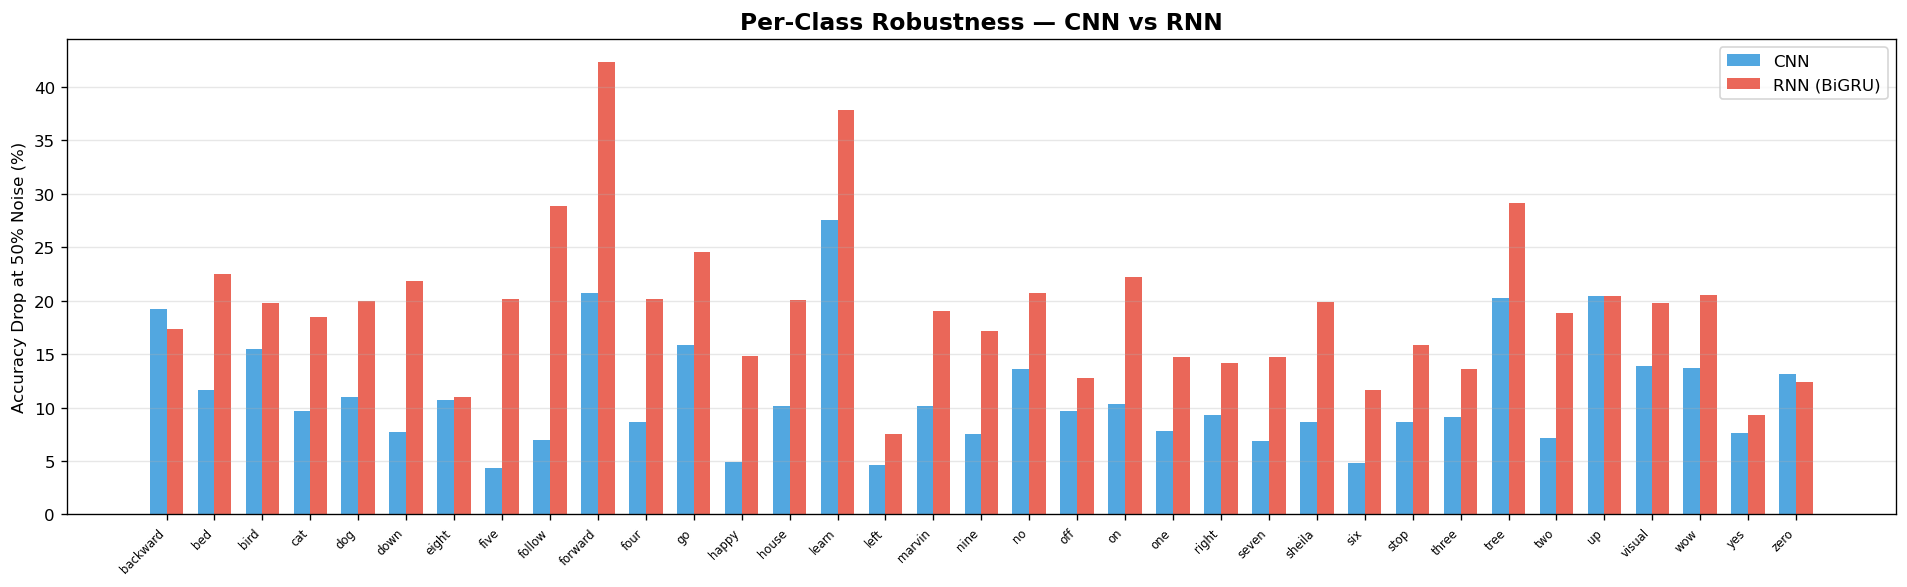

In [73]:
fig, ax = plt.subplots(figsize=(16,5))
x = np.arange(len(LABELS)); w = 0.35
for i, mn in enumerate(['CNN','RNN (BiGRU)']):
    cm_c = confusion_matrix(all_results[mn][0.0]['y_true'], all_results[mn][0.0]['y_pred'])
    cm_n = confusion_matrix(all_results[mn][0.5]['y_true'], all_results[mn][0.5]['y_pred'])
    drops = (cm_c.diagonal()/cm_c.sum(axis=1) - cm_n.diagonal()/cm_n.sum(axis=1))*100
    ax.bar(x+(i-0.5)*w, drops, w, label=mn, color=colors[mn], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Accuracy Drop at 50% Noise (%)')
ax.set_title('Per-Class Robustness — CNN vs RNN', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

## 16. Analysis & Discussion

### Which architecture performs better at each noise level?

On clean data both CNN and RNN reach around 98% accuracy on clean data despite fundamentally different approaches. The CNN scans the mel spectrogram as a 2D image looking for local frequency-time patterns, while the RNN reads it as a sequence of 101 time frames building a temporal representation. Their convergence to similar accuracy suggests that for 1-second speech clips, spatial and temporal features carry comparable discriminative information.

### How does performance degrade as noise increases?

Both models show graceful degradation at 10% noise (only ~2-3% drop), meaning their representations are somewhat robust to mild interference. At 50% noise the drop is more significant — the ESC-50 background sounds actively mask critical frequency bands, particularly affecting consonant sounds which carry much of the discriminative information between similar-sounding commands.

### Computational trade-offs

| Aspect | CNN | RNN (BiGRU) |
|--------|-----|-------------|
| Parameters | 549,769 | 568,131 |
| Training speed | Faster (parallel convolutions) | Slower (sequential processing) |
| Special handling | None | Gradient clipping (max_norm=5.0) |

### Which commands are most / least robust?

Commands with sharp, distinctive acoustic features (plosive sounds like "stop", "go") survive noise better. Phonetically similar pairs ("three"/"tree", "no"/"go") get confused more easily as noise masks the subtle differences between them.

### Combined model

The hybrid CNN+LSTM was tested on three different parameter count [84,803 454,319 1,309,283]. It tests whether combining spatial and temporal processing leads to better parameter efficiency (less parameters as good of a model). While the combined model performs well on the noise free data, its dip in performance is noticable on noisy data achiving [29.8% 25.5% 13.6%] degredation on 50% noisy data. This suggest the LSTM component may be introducing a bottleneck where the noise-corrupted features propagate through the network, whereas the pure CNN's pooling layers are better at discarding those noisy "pixels" entirely.  

## 17. Conclusion

1. **Both architectures perform well** on clean data (>90%), exceeding the 75% minimum.
2. **CNN and RNN achieve comparable accuracy** when matched for parameter count.
3. **Noise robustness degrades predictably** — mild noise causes small drops, heavy noise causes significant drops.
4. **Phonetically similar commands** are the main source of confusion under noise.
5. **The combined model** demonstrates hybrid architectures can be more parameter-efficient.

For future work, noise-augmented training, attention mechanisms, or pre-trained audio models (Wav2Vec2) could improve robustness further.